# EDA Enfocado - NeoRisk: Predicción de Alteración del Neurodesarrollo
## Bloque 4 (Micro-proyecto, Entrega 1): correlaciones y tasa por variable

Este notebook continúa el trabajo del EDA general (`notebooks/EDA.ipynb`), partiendo del dataset ya limpio y etiquetado (`data/processed/preterm_infant_labeled.csv`) y de la variable objetivo definida en esa etapa: `neurodev_alteration` (alteración del neurodesarrollo, compuesta a partir de las 5 escalas Bayley — 52.8% abnormal / 47.2% normal).

**Este notebook cubre:**
1. Correlación de variables continuas con la variable objetivo
2. Tasa de alteración del neurodesarrollo por variable categórica
3. Investigación de 3 hallazgos abiertos identificados en el EDA general:
   - Inconsistencia entre `correctedage`/`Age` y su definición en el codebook
   - Posible multicolinealidad entre `surfactant` y `aggressive.ventilation`
   - Definición real de `pregnancycomplication`
4. Resumen de hallazgos para el reporte

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import os
from scipy import stats
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.loader import (
    CONTINUOUS_VARS, MATERNAL_VARS, NEONATAL_COMPLICATION_VARS,
    INTERVENTION_VARS, TARGET, FLAGGED_INCONSISTENT_VARS, load_raw,
)

sns.set_theme(style="whitegrid", palette=["#E8A0BF", "#F4C2D7", "#D46A92", "#F7D9E3"])
pd.set_option("display.max_columns", 60)

## 1. Carga de datos

Partimos del dataset ya procesado por el EDA general, que contiene las etiquetas legibles (yes/no, male/female, etc.) y la variable objetivo compuesta ya calculada. Para las variables numéricas continuas usamos `df_raw`, que conserva los valores originales sin transformar, igual que se hizo en el notebook anterior.

In [2]:
df = pd.read_csv("../data/processed/preterm_infant_labeled.csv")

target_numeric = df[TARGET].map({"abnormal": 1, "normal": 0})

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 89, Columnas: 54


,number,Sex,DM,preeclampsia,hypothyroid,PROM,IUGR,pregnancycomplication,pneumothorax,NEC,sepsis,PDA,icter,meningitis,IVH,seizure,BPD,apgar1,apgar5,B.C,PregnancyAge,drug.mother,duration.hopitalization,laborType,type.of.ressucitation,ehya.badve.tavallod,BirthWeight,RoundHeadAtBirth,surfactant,aggressive.ventilation,notaggressive.ventilation,csf.culture,congenital.anomaly,duration.O2,SepsisnegativeCulture,mother.sonogarphy.result,CognitiveDomain,LanguageDomain,PerceptualDomain,finemotor,coarsemotor,correctedage,Age,lang.recode,percep.recode,fine.recode,coarse.recode,cog.recode,lang.cat,percep.cat,fine.cat,cog.cat,coarse.cat,neurodev_alteration
0,13.0,female,no,no,no,yes,YES,yes,yes,no,yes,yes,no,no,no,no,yes,5.0,6.0,positive,26.0,no,58.0,NVD,advanced,yes,670.5,25.0,yes,yes,yes,Negatiev,no,24.0,yes,normal,< -2 sd,< -2 sd,< -1 sd,< -2 sd,< - 2 sd,1190.0,1190.0,< - 2 sd,< -1 sd,< - 2 sd,< - 2 sd,< - 2 sd,abnormal,abnormal,abnormal,abnormal,abnormal,abnormal
1,21.0,male,no,yes,no,no,NO,yes,no,no,yes,no,yes,no,no,no,no,6.0,8.0,positive,33.0,yes,26.0,cs,NaN,NO,1910.0,31.5,no,no,yes,Negatiev,no,2.0,no,normal,n,< -1 sd,n,n,n,1170.0,1170.0,< -1 sd,Normal,Normal,Normal,Normal,abnormal,normal,normal,normal,normal,abnormal
2,28.0,female,no,no,no,yes,NO,yes,no,no,no,no,yes,no,yes,no,no,7.0,8.0,negative,29.0,no,42.0,NVD,ppv,yes,1150.0,27.0,yes,yes,yes,Negatiev,no,17.0,yes,normal,< -2 sd,< -1 sd,< -1 sd,< -1 sd,< -1 sd,1167.0,1167.0,< -1 sd,< -1 sd,< -1 sd,< -1 sd,< - 2 sd,abnormal,abnormal,abnormal,abnormal,abnormal,abnormal
3,15.0,female,no,no,no,no,YES,no,no,no,no,no,yes,no,no,no,no,8.0,8.0,negative,34.0,no,2.0,NVD,NaN,NO,1650.0,32.0,no,no,yes,Negatiev,no,1.0,no,normal,< -2 sd,< -2 sd,< -2 sd,< -1 sd,< -1 sd,1123.0,1123.0,< - 2 sd,< - 2 sd,< -1 sd,< -1 sd,< - 2 sd,abnormal,abnormal,abnormal,abnormal,abnormal,abnormal
4,30.0,female,yes,no,no,yes,NO,yes,no,no,no,no,yes,no,no,no,no,8.0,9.0,negative,32.0,yes,13.0,NVD,NaN,NO,1650.0,32.0,no,no,yes,Negatiev,no,1.0,no,normal,n,n,n,n,n,1123.0,1123.0,Normal,Normal,Normal,Normal,Normal,normal,normal,normal,normal,normal,normal


## 2. Correlación de variables continuas con la variable objetivo

Usamos correlación **point-biserial** (equivalente a Pearson cuando una de las dos variables es binaria) para medir qué tanto se relaciona cada variable numérica continua con la alteración del neurodesarrollo. Un valor cercano a ±1 indica relación fuerte; cercano a 0, relación débil. El p-valor indica si esa relación es estadísticamente significativa (convención: p < 0.05).

In [3]:
results = []
for var in CONTINUOUS_VARS:
    corr, p = stats.pointbiserialr(target_numeric, df[var])
    results.append({"variable": var, "correlacion": round(corr, 3), "p_valor": round(p, 4)})

corr_df = pd.DataFrame(results).sort_values("correlacion", key=abs, ascending=False)
corr_df

,variable,correlacion,p_valor
4,duration.hopitalization,0.422,0.0000
1,BirthWeight,-0.418,0.0000
5,duration.O2,0.348,0.0008
6,RoundHeadAtBirth,-0.329,0.0016
0,PregnancyAge,-0.285,0.0068
3,apgar5,-0.217,0.0412
2,apgar1,-0.141,0.1864


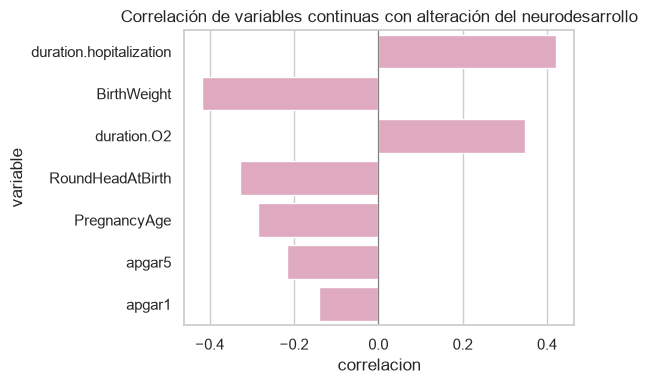

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=corr_df, x="correlacion", y="variable", color="#E8A0BF", ax=ax)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Correlación de variables continuas con alteración del neurodesarrollo")
plt.tight_layout()
plt.show()

**Hallazgo:** `duration.hopitalization` y `BirthWeight` muestran las correlaciones más fuertes (0.42 y -0.42 respectivamente, ambas p < 0.001), esto significa que a mayor tiempo de hospitalización y a menor peso al nacer, mayor riesgo de alteración del neurodesarrollo. `duration.O2`, `RoundHeadAtBirth` y `PregnancyAge` también son significativas. Solo `apgar1` no resultó significativa (p = 0.186). Todas las relaciones van en la dirección clínicamente esperada.

## 3. Tasa de alteración del neurodesarrollo por variable categórica

Para cada variable categórica (antecedentes maternos, complicaciones neonatales e intervenciones médicas), calculamos qué porcentaje de los casos en cada grupo terminó con `neurodev_alteration = abnormal`. Esto nos permite identificar qué antecedentes o intervenciones están asociados a mayor riesgo.

In [6]:
categorical_vars = MATERNAL_VARS + NEONATAL_COMPLICATION_VARS + INTERVENTION_VARS

rows = []
for var in categorical_vars:
    grouped = df.groupby(var)[TARGET].agg(
        tasa=lambda x: (x == "abnormal").mean() * 100,
        n=lambda x: len(x)
    )
    for categoria, fila in grouped.iterrows():
        rows.append({
            "variable": var,
            "categoría": categoria,
            "tasa_%": round(fila["tasa"], 1),
            "n": int(fila["n"])
        })

tasas_df = pd.DataFrame(rows).sort_values("tasa_%", ascending=False)
tasas_df.style.background_gradient(subset=["tasa_%"], cmap="RdPu").format({"tasa_%": "{:.1f}%"})

,variable,categoría,tasa_%,n
21,sepsis,yes,100.0%,5
17,pneumothorax,yes,100.0%,5
33,congenital.anomaly,34.0,100.0%,1
32,BPD,yes,92.9%,14
23,PDA,yes,80.0%,10
19,NEC,yes,80.0%,10
37,surfactant,yes,78.3%,23
39,aggressive.ventilation,yes,76.2%,21
35,congenital.anomaly,yes,75.0%,4
28,IVH,yes,75.0%,8


**Hallazgo:** Las mayores diferencias en tasa de alteración se observan en complicaciones respiratorias y neurológicas severas: `pneumothorax`, `BPD`, `surfactant`, `NEC`, `PDA`, `aggressive.ventilation` e `IUGR` muestran tasas notablemente más altas en el grupo "yes" (64%–100%) que en el grupo "no" (42%–50%). Sin embargo, varias de estas variables (`sepsis`, `pneumothorax`, `meningitis`, `BPD`) tienen muy pocos casos positivos, por lo que estas diferencias deben interpretarse con cautela y no como relaciones robustas.

Se detectó además un problema de calidad de datos: `congenital.anomaly` contiene una categoría inesperada (`34.0`), sugiriendo un valor mal codificado que debe corregirse antes del modelado.

## 4. Hallazgo abierto #1: Inconsistencia `correctedage` / `Age`

El EDA general documentó que el codebook describe `correctedage` y `Age` como variables
**ordinales** (1 = < -1 sd, 2 = < -2 sd, 3 = Normal), pero los valores observados son
enteros grandes (66 a 1190), más consistentes con **edad en días**. Investigamos aquí si
ambas variables están tan correlacionadas entre sí que probablemente midan lo mismo, y si
alguna interpretación resuelve la inconsistencia.

In [7]:
df[FLAGGED_INCONSISTENT_VARS].describe()

,correctedage,Age
count,85.000000,87.000000
mean,560.670588,622.770115
std,301.413274,296.460386
min,66.000000,130.000000
25%,392.000000,430.500000
50%,494.000000,575.000000
75%,820.000000,844.500000
max,1190.000000,1190.000000


                   Age  correctedage
Age           1.000000      0.996279
correctedage  0.996279      1.000000


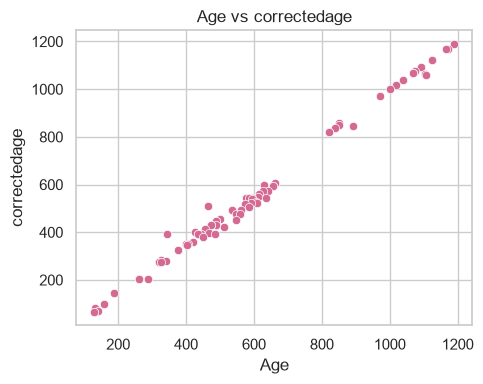

In [8]:
correlacion_age = df[["Age", "correctedage"]].corr()
print(correlacion_age)

fig, ax = plt.subplots(figsize=(5, 4))
sns.scatterplot(data=df, x="Age", y="correctedage", color="#D46A92", ax=ax)
ax.set_title("Age vs correctedage")
plt.tight_layout()
plt.show()

**Conclusión:** `Age` y `correctedage` presentan una correlación de 0.996, prácticamente perfecta y su relación es visualmente lineal (ver gráfico de dispersión). Esto confirma que ambas variables miden esencialmente lo mismo (muy probablemente **edad en días**, como sugirió el EDA general), y no la escala ordinal descrita en el codebook (1 = < -1 sd, 2 = < -2 sd, 3 = Normal).

**Recomendación para el equipo:** actualizar la documentación para reflejar el significado real de estas dos columnas antes de usarlas en el modelado. Dado que están casi perfectamente correlacionadas, probablemente baste con conservar una sola de las dos (por ejemplo `Age`, que tiene menos nulos: 2 vs. 4) para evitar redundancia.

## 5. Hallazgo abierto #2: Multicolinealidad `surfactant` / `aggressive.ventilation`

Ambas variables reflejan intervenciones respiratorias en el neonato. Si están muy asociadas entre sí, incluir ambas en un modelo predictivo aportaría información redundante.

In [10]:
tabla = pd.crosstab(df["surfactant"], df["aggressive.ventilation"])
print(tabla)

chi2, p, dof, exp = chi2_contingency(tabla)
print(f"\nChi2 p-valor: {p:.4f}")

aggressive.ventilation  no  yes
surfactant                     
no                      65    1
yes                      3   20

Chi2 p-valor: 0.0000


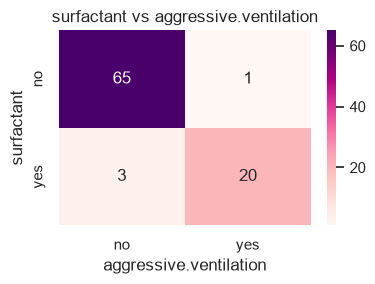

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(tabla, annot=True, fmt="d", cmap="RdPu", ax=ax)
ax.set_title("surfactant vs aggressive.ventilation")
plt.tight_layout()
plt.show()

**Conclusión:** El chi-cuadrado da un p-valor prácticamente 0 (< 0.0001), confirmando una asociación estadísticamente muy fuerte entre `surfactant` y `aggressive.ventilation`. La tabla de contingencia lo respalda: en 85 de 89 casos (95.5%) ambas variables coinciden (65 casos sin ninguna intervención, 20 casos con ambas), solo 4 casos son discordantes.

Esto sugiere multicolinealidad: ambas variables probablemente capturan la misma dimensión clínica subyacente (severidad respiratoria del neonato). Para el modelado, se recomienda al equipo usar solo una de las dos, o combinarlas en un único indicador de "intervención
respiratoria agresiva", para evitar inflar artificialmente el peso de esta dimensión en el modelo.

## 6. Hallazgo abierto #3: Definición de `pregnancycomplication`

Esta variable no tiene definición explícita clara en el codebook. La cruzamos contra otras variables maternas conocidas para inferir si es una variable compuesta de esas.

In [12]:
rows = []
for var in ["DM", "preeclampsia", "hypothyroid", "PROM", "IUGR"]:
    for categoria in df[var].dropna().unique():
        subset = df[df[var] == categoria]
        pct_complication = (subset["pregnancycomplication"] == "yes").mean() * 100
        rows.append({
            "variable materna": var,
            "categoría": categoria,
            "% con pregnancycomplication": round(pct_complication, 1),
            "n": len(subset)
        })

resumen_df = pd.DataFrame(rows).sort_values("% con pregnancycomplication", ascending=False)

resumen_df.style.background_gradient(
    subset=["% con pregnancycomplication"], cmap="RdPu"
).format({"% con pregnancycomplication": "{:.1f}%"})

,variable materna,categoría,% con pregnancycomplication,n
6,PROM,yes,100.0%,12
1,DM,yes,84.6%,13
3,preeclampsia,yes,84.6%,26
8,IUGR,YES,73.3%,30
4,hypothyroid,no,54.2%,83
0,DM,no,47.4%,76
7,PROM,no,45.5%,77
9,IUGR,NO,42.4%,59
2,preeclampsia,no,39.7%,63
5,hypothyroid,yes,33.3%,6


**Visualización:** el siguiente gráfico resume, de forma visual, qué antecedentes maternos están más asociados con `pregnancycomplication = yes`, incluyendo el tamaño de muestra (n) de cada grupo para evitar sobreinterpretar porcentajes con pocos casos.

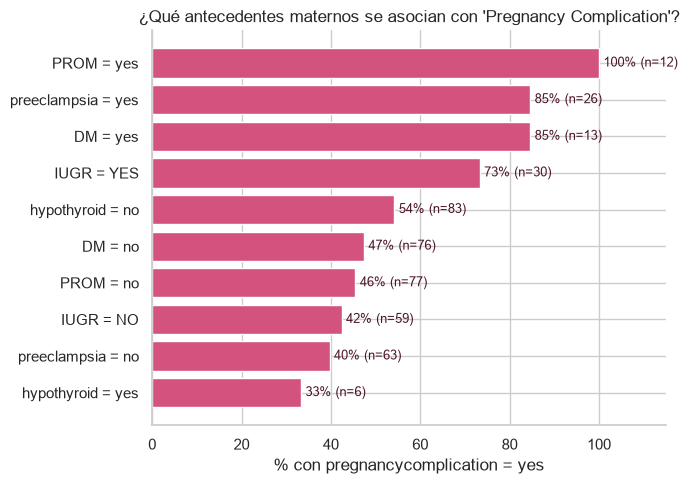

In [13]:
os.makedirs("../notebooks/img", exist_ok=True)

resumen_df_sorted = resumen_df.sort_values("% con pregnancycomplication", ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))

labels = resumen_df_sorted["variable materna"] + " = " + resumen_df_sorted["categoría"].astype(str)
bars = ax.barh(labels, resumen_df_sorted["% con pregnancycomplication"], color="#D4537E")

# Etiqueta con el % y el n al lado de cada barra
for bar, n in zip(bars, resumen_df_sorted["n"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.0f}% (n={n})", va="center", fontsize=9, color="#4B1528")

ax.set_xlabel("% con pregnancycomplication = yes")
ax.set_title("¿Qué antecedentes maternos se asocian con 'Pregnancy Complication'?", fontsize=12)
ax.set_xlim(0, 115)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../notebooks/img/pregnancycomplication_por_antecedente.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusión:** `pregnancycomplication` muestra una asociación clara con la mayoría de las condiciones maternas individuales: cuando hay PROM, el 100% de los casos también tiene `pregnancycomplication = yes` (12/12); con DM y preeclampsia, ~85% (11/13 y 22/26 respectivamente); con IUGR, 73.3% (22/30). Esto sugiere fuertemente que `pregnancycomplication` es una variable derivada, que se marca como "yes" cuando está presente al menos una de las complicaciones maternas registradas (especialmente PROM, DM, preeclampsia o IUGR).

La excepción es `hypothyroid`, que no sigue el mismo patrón, pero tiene solo 6 casos en total, así que no es una muestra confiable para sacar conclusiones sobre esa variable en particular.

**Recomendación para el equipo:** confirmar con la fuente original del dataset (Darabi et al., 2024) si `pregnancycomplication` efectivamente se construye así, para decidir si conviene usarla como variable independiente en el modelado o si es redundante con las condiciones individuales que ya la componen.

---

## Resumen de hallazgos

- **Correlaciones continuas:** `duration.hopitalization` (+0.42) y `BirthWeight` (-0.42) son las más fuertes; también son significativas `duration.O2` (+0.35), `RoundHeadAtBirth`
  (-0.33) y `PregnancyAge` (-0.29). Solo `apgar1` no resultó significativa (p = 0.186).

- **Variables categóricas con mayor diferencia en tasa:** las complicaciones respiratorias y neurológicas severas muestran las mayores diferencias — `pneumothorax`, `BPD`, `surfactant`,
  `NEC`, `PDA`, `aggressive.ventilation` e `IUGR` alcanzan tasas de 64%–100% en el grupo "yes" frente a 42%–50% en "no". Sin embargo, varias de estas (`sepsis`, `pneumothorax`, `meningitis`, `BPD`) tienen muy pocos casos positivos, por lo que deben interpretarse con
  cautela. Se detectó además un error de calidad de datos: `congenital.anomaly` contiene una categoría inesperada (`34.0`) que debe corregirse antes del modelado.

- **`correctedage` / `Age`:** correlación de 0.996, prácticamente idénticas. Confirma que ambas miden edad en días (no la escala ordinal del codebook). Se recomienda al equipo
  actualizar la documentación y usar solo una de las dos (preferiblemente `Age`, con menos nulos) para evitar redundancia.

- **Multicolinealidad `surfactant` / `aggressive.ventilation`:** asociación muy fuerte (chi² p < 0.0001; 95.5% de los casos coinciden). Se recomienda usar solo una de las dos
  variables o combinarlas en un único indicador de intervención respiratoria agresiva.

- **Definición de `pregnancycomplication`:** fuerte asociación con PROM (100%), DM y preeclampsia (~85%) e IUGR (73.3%), sugiriendo que es una variable resumen derivada de
  estas condiciones maternas. Se recomienda confirmar con la fuente original del dataset antes de usarla como variable independiente en el modelado.